In [7]:
library(TwoSampleMR)
library(dplyr)
library(ggplot2)
library(ieugwasr)

OpenGWAS updates:

  Date: 2024-05-17

  [>] OpenGWAS is growing!

  [>] Please take 2 minutes to give us feedback -

  [>] It will help directly shape our emerging roadmap

  [>] https://forms.office.com/e/eSr7EFAfCG


Attaching package: ‘ieugwasr’


The following object is masked from ‘package:TwoSampleMR’:

    ld_matrix




Let's use the 2015 GWAS for Coronary Artery Disease as an example. 

- Identify the GWAS hits for CAD
- Choose one as an example
- Objective: are there any traits that appear to mediate the path from SNP -> CHD
- For candidate traits, use MR to test if it's associated with CHD

In [ ]:
chd <- TwoSampleMR::extract_instruments("ieu-a-7")
str(chd)

'data.frame':	41 obs. of  15 variables:
 $ id.exposure           : chr  "ieu-a-7" "ieu-a-7" "ieu-a-7" "ieu-a-7" ...
 $ chr.exposure          : chr  "9" "6" "6" "1" ...
 $ pos.exposure          : int  22098619 12903957 161005610 109817192 203893999 79124475 160687412 35593827 11188247 44480811 ...
 $ SNP                   : chr  "rs2891168" "rs9349379" "rs55730499" "rs7528419" ...
 $ effect_allele.exposure: chr  "G" "G" "T" "G" ...
 $ other_allele.exposure : chr  "A" "A" "C" "A" ...
 $ eaf.exposure          : num  0.4887 0.4316 0.0562 0.2142 0.107 ...
 $ beta.exposure         : num  0.193 0.132 0.317 -0.115 0.138 ...
 $ se.exposure           : num  0.00919 0.00965 0.02424 0.01148 0.01583 ...
 $ pval.exposure         : num  2.29e-98 1.81e-42 5.39e-39 1.97e-23 3.12e-18 ...
 $ samplesize.exposure   : num  184305 184305 184305 184305 184305 ...
 $ exposure              : chr  "Coronary heart disease || id:ieu-a-7" "Coronary heart disease || id:ieu-a-7" "Coronary heart disease || id:ieu-a-7"

For illustration let's look at just the first SNP in the list. What traits might mediate the path from this SNP to the outcome?

In [4]:
snp <- chd$SNP[1]
snp

[1] "rs2891168"

In [9]:
phewas_result <- ieugwasr::phewas(snp, batch="ukb-b")
str(phewas_result)

tibble [84 × 12] (S3: tbl_df/tbl/data.frame)
 $ id      : chr [1:84] "ukb-b-1668" "ukb-b-18408" "ukb-b-8650" "ukb-b-8468" ...
 $ trait   : chr [1:84] "Diagnoses - main ICD10: I25.1 Atherosclerotic heart disease" "Illnesses of father: Heart disease" "Non-cancer illness code, self-reported: angina" "Vascular/heart problems diagnosed by doctor: Angina" ...
 $ chr     : chr [1:84] "9" "9" "9" "9" ...
 $ position: int [1:84] 22098619 22098619 22098619 22098619 22098619 22098619 22098619 22098619 22098619 22098619 ...
 $ rsid    : chr [1:84] "rs2891168" "rs2891168" "rs2891168" "rs2891168" ...
 $ ea      : chr [1:84] "G" "G" "G" "G" ...
 $ nea     : chr [1:84] "A" "A" "A" "A" ...
 $ eaf     : num [1:84] 0.49 0.49 0.49 0.49 0.49 ...
 $ beta    : num [1:84] 0.00586 0.01652 0.00503 0.00498 0.00238 ...
 $ se      : num [1:84] 0.00033 0.001037 0.000364 0.000365 0.00018 ...
 $ p       : num [1:84] 2.2e-70 4.1e-57 2.0e-43 2.3e-42 5.0e-40 ...
 $ n       : num [1:84] 463010 407557 462933 461880 462933

In [12]:
for(i in 1:nrow(phewas_result)) {
  message(i, ": ", phewas_result$p[i], " - ", phewas_result$trait[i])
}

1: 2.19989e-70 - Diagnoses - main ICD10: I25.1 Atherosclerotic heart disease

2: 4.10015e-57 - Illnesses of father: Heart disease

3: 1.99986e-43 - Non-cancer illness code, self-reported: angina

4: 2.29985e-42 - Vascular/heart problems diagnosed by doctor: Angina

5: 5.00035e-40 - Operation code: coronary artery bypass grafts (cabg)

6: 4.79954e-39 - Non-cancer illness code, self-reported: heart attack/myocardial infarction

7: 5.70033e-38 - Vascular/heart problems diagnosed by doctor: Heart attack

8: 6.70039e-33 - Diagnoses - secondary ICD10: Z95.1 Presence of aortocoronary bypass graft

9: 2.19989e-31 - Diagnoses - secondary ICD10: I20.9 Angina pectoris, unspecified

10: 7.50067e-30 - Operative procedures - main OPCS: K45.3 Anastomosis of mammary artery to left anterior descending coronary artery

11: 1.10002e-29 - Treatment speciality of consultant (recoded): Cardiology

12: 1.99986e-29 - Operation code: coronary angioplasty (ptca) +/- stent

13: 7.00003e-29 - Diagnoses - secondar

In [19]:
follow_up <- phewas_result$id[c(46, 67)]
follow_up_instruments <- extract_instruments(outcomes = follow_up)
str(follow_up_instruments)

Warning message in FUN(X[[i]], ...):
“Duplicated SNPs present in exposure data for phenotype 'Diastolic blood pressure, automated reading || id:ukb-b-7992. Just keeping the first instance:
rs28752924”


'data.frame':	281 obs. of  15 variables:
 $ id.exposure           : chr  "ukb-b-17324" "ukb-b-17324" "ukb-b-17324" "ukb-b-17324" ...
 $ chr.exposure          : chr  "1" "9" "4" "17" ...
 $ pos.exposure          : int  165739598 22036367 7888830 10031183 107695848 129375338 61091401 637465 108276873 14837332 ...
 $ SNP                   : chr  "rs2814471" "rs1556515" "rs55937650" "rs9913911" ...
 $ effect_allele.exposure: chr  "T" "T" "T" "G" ...
 $ other_allele.exposure : chr  "C" "C" "C" "A" ...
 $ eaf.exposure          : num  0.876 0.57 0.594 0.374 0.556 ...
 $ beta.exposure         : num  -0.01554 0.00698 -0.00663 -0.00644 -0.00614 ...
 $ se.exposure           : num  0.001123 0.000745 0.000752 0.000764 0.000748 ...
 $ pval.exposure         : num  1.5e-43 7.2e-21 1.2e-18 3.6e-17 2.3e-16 ...
 $ samplesize.exposure   : num  150642 150642 150642 150642 150642 ...
 $ exposure              : chr  "Eye problems/disorders: Glaucoma || id:ukb-b-17324" "Eye problems/disorders: Glaucoma || id:

In [20]:
i <- which(chd$SNP == snp)

follow_up_instruments_target_region <- follow_up_instruments %>%
    filter(chr.exposure == chd$chr.exposure[i] & abs(pos.exposure - chd$pos.exposure[i]) < 1e6) %>%
    mutate(
        id.exposure = paste("target region - ", id.exposure),
        exposure = paste("target region - ", exposure)
    )
str(follow_up_instruments_target_region)


'data.frame':	2 obs. of  15 variables:
 $ id.exposure           : chr  "target region -  ukb-b-17324" "target region -  ukb-b-7992"
 $ chr.exposure          : chr  "9" "9"
 $ pos.exposure          : int  22036367 22003223
 $ SNP                   : chr  "rs1556515" "rs3217992"
 $ effect_allele.exposure: chr  "T" "T"
 $ other_allele.exposure : chr  "C" "C"
 $ eaf.exposure          : num  0.57 0.369
 $ beta.exposure         : num  0.00698 -0.01334
 $ se.exposure           : num  0.000745 0.002146
 $ pval.exposure         : num  7.2e-21 5.2e-10
 $ samplesize.exposure   : num  150642 436424
 $ exposure              : chr  "target region -  Eye problems/disorders: Glaucoma || id:ukb-b-17324" "target region -  Diastolic blood pressure, automated reading || id:ukb-b-7992"
 $ mr_keep.exposure      : logi  TRUE TRUE
 $ pval_origin.exposure  : chr  "reported" "reported"
 $ data_source.exposure  : chr  "igd" "igd"


In [21]:
follow_up_instruments <- subset(follow_up_instruments, !SNP %in% follow_up_instruments_target_region$SNP) %>% 
    bind_rows(follow_up_instruments_target_region)
table(follow_up_instruments$exposure)


                 Diastolic blood pressure, automated reading || id:ukb-b-7992 
                                                                          262 
                           Eye problems/disorders: Glaucoma || id:ukb-b-17324 
                                                                           17 
target region -  Diastolic blood pressure, automated reading || id:ukb-b-7992 
                                                                            1 
          target region -  Eye problems/disorders: Glaucoma || id:ukb-b-17324 
                                                                            1 

In [22]:
out <- extract_outcome_data(snps = follow_up_instruments$SNP, outcomes = "ieu-a-7")
dat <- harmonise_data(follow_up_instruments, out, action = 3)
mr_result <- mr(dat, method_list=c("mr_ivw", "mr_wald_ratio"))

Extracting data for 281 SNP(s) from 1 GWAS(s)

Querying id chunk 1 of 1

Querying variant chunk 1 of 5

Querying variant chunk 2 of 5

Querying variant chunk 3 of 5

Querying variant chunk 4 of 5

Querying variant chunk 5 of 5

Finding proxies for 5 SNPs in outcome ieu-a-7

Extracting data for 5 SNP(s) from 1 GWAS(s)

Querying id chunk 1 of 1

Querying variant chunk 1 of 1

Warning message in `[.data.table`(d, !duplicated(proxy_snp.outcome), , by = outcome):
“Ignoring by/keyby because 'j' is not supplied”
Harmonising Diastolic blood pressure, automated reading || id:ukb-b-7992 (ukb-b-7992) and Coronary heart disease || id:ieu-a-7 (ieu-a-7)

Removing the following SNPs for being palindromic:
rs10260816, rs10850529, rs10890238, rs11021221, rs11026585, rs11222084, rs1123037, rs11592442, rs12258967, rs12611608, rs12905116, rs13004226, rs13163533, rs1325345, rs13429113, rs200373, rs2164820, rs2229902, rs2274224, rs2612016, rs28667801, rs34966754, rs35021474, rs4306343, rs4507656, rs57333327

In [23]:
mr_result

id.exposure,id.outcome,outcome,exposure,method,nsnp,b,se,pval
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
ukb-b-7992,ieu-a-7,Coronary heart disease || id:ieu-a-7,"Diastolic blood pressure, automated reading || id:ukb-b-7992",Inverse variance weighted,219,0.5968246,0.07740218,1.251344e-14
ukb-b-17324,ieu-a-7,Coronary heart disease || id:ieu-a-7,Eye problems/disorders: Glaucoma || id:ukb-b-17324,Inverse variance weighted,15,1.0113659,0.48597125,3.742266e-02
target region - ukb-b-17324,ieu-a-7,Coronary heart disease || id:ieu-a-7,target region - Eye problems/disorders: Glaucoma || id:ukb-b-17324,Wald ratio,1,15.6902580,2.37510702,3.945052e-11
target region - ukb-b-7992,ieu-a-7,Coronary heart disease || id:ieu-a-7,"target region - Diastolic blood pressure, automated reading || id:ukb-b-7992",Wald ratio,1,-9.6217063,0.70237399,1.031644e-42


`height` was translated to `width`.


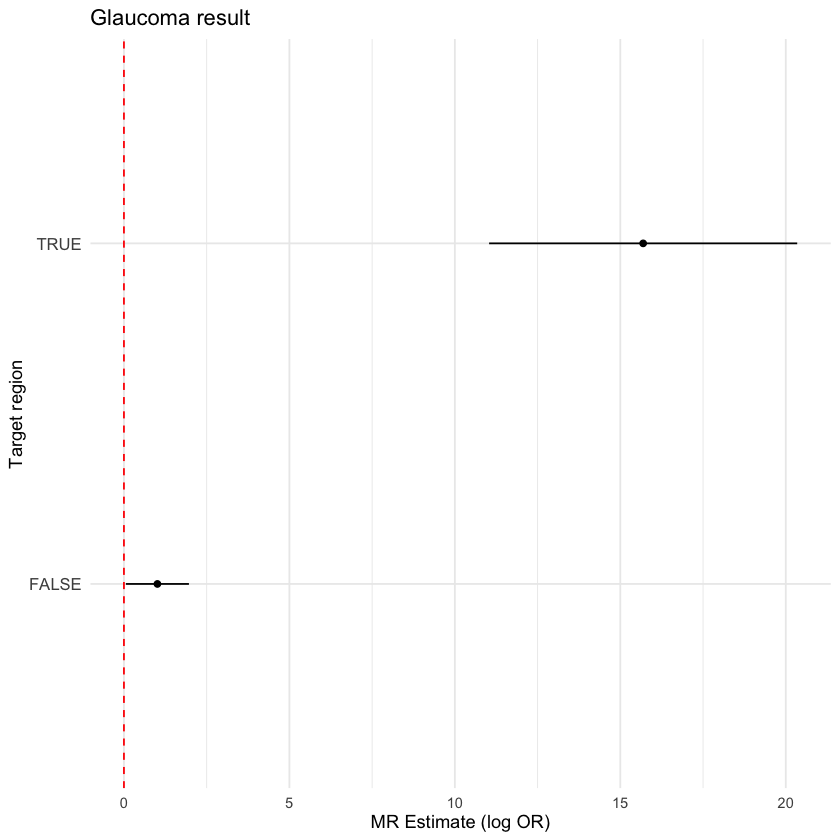

In [26]:
ggplot(mr_result %>% filter(grepl("Glauc", exposure)), aes(x=b, y=grepl("target region", exposure))) +
geom_point() +
geom_errorbarh(aes(xmin=b-1.96*se, xmax=b+1.96*se), height=0) +
theme_minimal() +
geom_vline(xintercept=0, linetype="dashed", color="red") +
labs(x="MR Estimate (log OR)", y="Target region", title="Glaucoma result") +
theme(axis.text.y = element_text(size=10))

`height` was translated to `width`.


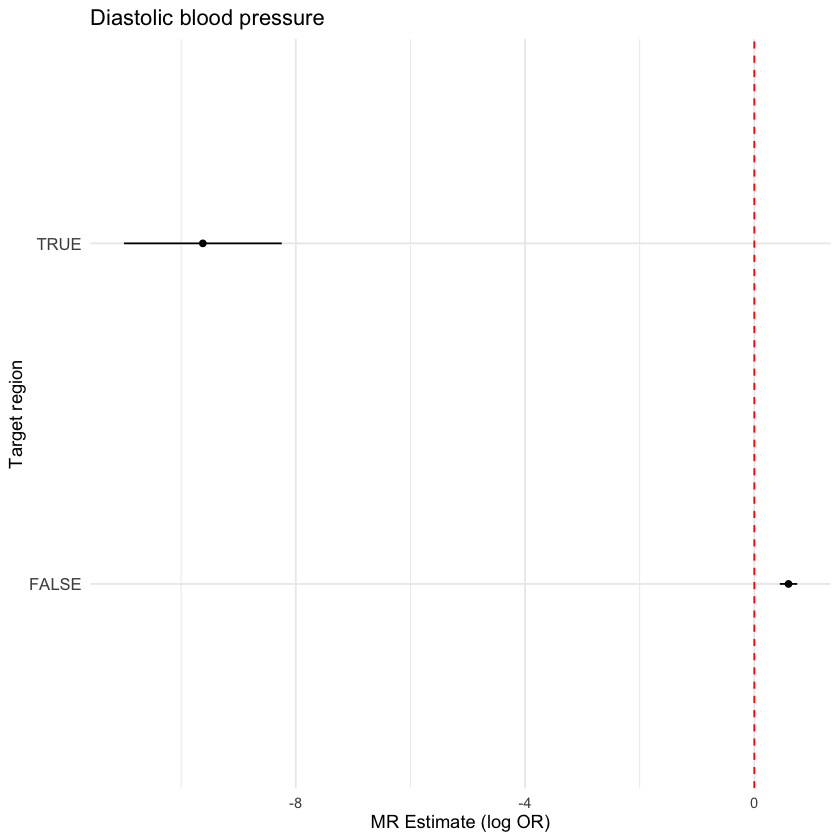

In [27]:
ggplot(mr_result %>% filter(grepl("pressure", exposure)), aes(x=b, y=grepl("target region", exposure))) +
geom_point() +
geom_errorbarh(aes(xmin=b-1.96*se, xmax=b+1.96*se), height=0) +
theme_minimal() +
geom_vline(xintercept=0, linetype="dashed", color="red") +
labs(x="MR Estimate (log OR)", y="Target region", title="Diastolic blood pressure") +
theme(axis.text.y = element_text(size=10))

Warning message in FUN(X[[i]], ...):
“Duplicated SNPs present in exposure data for phenotype 'Diastolic blood pressure, automated reading || id:ukb-b-7992. Just keeping the first instance:
rs28752924”
Extracting data for 263 SNP(s) from 1 GWAS(s)

Querying id chunk 1 of 1

Querying variant chunk 1 of 5

Querying variant chunk 2 of 5

Querying variant chunk 3 of 5

Querying variant chunk 4 of 5

Querying variant chunk 5 of 5

Finding proxies for 5 SNPs in outcome ieu-a-7

Extracting data for 5 SNP(s) from 1 GWAS(s)

Querying id chunk 1 of 1

Querying variant chunk 1 of 1

Warning message in `[.data.table`(d, !duplicated(proxy_snp.outcome), , by = outcome):
“Ignoring by/keyby because 'j' is not supplied”
Harmonising Diastolic blood pressure, automated reading || id:ukb-b-7992 (ukb-b-7992) and Coronary heart disease || id:ieu-a-7 (ieu-a-7)

Removing the following SNPs for incompatible alleles:
rs17304212

Warning message:
“Removed 1 row containing missing values or values outside the scal

[[1]]


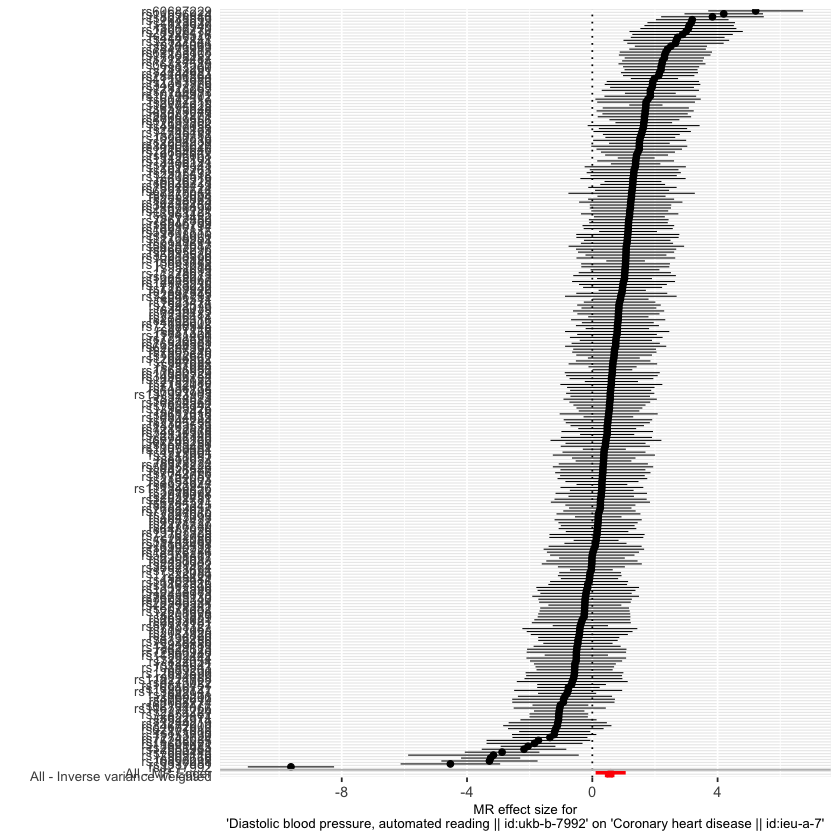

In [28]:
res <- make_dat("ukb-b-7992", "ieu-a-7")
mr_forest_plot(mr_singlesnp(res))